In [3]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Load the data
# (Assuming your notebook is in the same folder as the CSVs)
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# 2. Define the columns to drop entirely
cols_to_drop = [
    'INDEX_NR', 'REG', 'FLT', 'BIRD_BAND_NUMBER', 'LUPDATE', 'TRANSFER', 
    'REMARKS', 'LOCATION', 'COMMENTS', 'INCIDENT_DATE', 'AIRPORT', 
    'AIRPORT_ID', 'LATITUDE', 'LONGITUDE', 'AIRCRAFT', 'AMA', 'AMO', 
    'EMA', 'EMO', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 
    'REMAINS_COLLECTED', 'REMAINS_SENT', 'SOURCE', 'PERSON'
]

# Drop from both train and test sets
# Using errors='ignore' just in case a column isn't in the test set
train_df = train_df.drop(columns=cols_to_drop, errors='ignore')
test_df = test_df.drop(columns=cols_to_drop, errors='ignore')

# 3. Separate features (X) and target (y) for the training data
X_train = train_df.drop(columns=['INDICATED_DAMAGE'])
y_train = train_df['INDICATED_DAMAGE']
X_test = test_df.copy() # Test set doesn't have INDICATED_DAMAGE

# 4. Group the remaining features based on how we want to treat them
# Numerical features -> Impute with median, then scale
num_features = ['SPEED', 'HEIGHT', 'DISTANCE', 'INCIDENT_MONTH', 'INCIDENT_YEAR']

# Categorical features -> Impute with mode (most frequent), then One-Hot Encode
cat_mode_features = [
    'SIZE', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'AC_CLASS', 
    'NUM_STRUCK', 'NUM_SEEN', 'SPECIES_ID', 'SPECIES', 
    'OPID', 'OPERATOR', 'STATE', 'FAAREGION', 'RUNWAY', 
    'ENROUTE_STATE', 'WARNED', 'OUT_OF_RANGE_SPECIES'
]

# Environmental features -> Impute with "Unknown", then One-Hot Encode
cat_unknown_features = ['PHASE_OF_FLIGHT', 'TIME_OF_DAY', 'SKY', 'PRECIPITATION']

# 5. Build the individual transformer pipelines
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) # Standardizing helps models like Logistic Regression/SVM
])

# Updated to prevent feature explosion
cat_mode_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # THE FIX: max_categories=20 limits the output. 
    # It keeps the top 19 most frequent values and lumps the rest into an 'infrequent' column.
    ('encoder', OneHotEncoder(max_categories=20, handle_unknown='infrequent_if_exist', sparse_output=False)) 
])

cat_unknown_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(max_categories=10, handle_unknown='infrequent_if_exist', sparse_output=False))
])

# 6. Combine everything into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat_mode', cat_mode_transformer, cat_mode_features),
        ('cat_unk', cat_unknown_transformer, cat_unknown_features)
    ],
    remainder='drop' # Drops any columns we might have missed in the lists above
)

# 7. Execute the preprocessing!
# Fit on the training data, then transform both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Optional: Get the new feature names out of the OneHotEncoder if you need to see them
feature_names = preprocessor.get_feature_names_out()
print(f"Original feature count: {X_train.shape[1]}")
print(f"New encoded feature count: {X_train_processed.shape[1]}")

/tmp/ipykernel_2105129/1637370679.py:9: DtypeWarning: Columns (8,9,20) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('train.csv')
/tmp/ipykernel_2105129/1637370679.py:10: DtypeWarning: Columns (8,9,20,37) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv('test.csv')


Original feature count: 27
New encoded feature count: 221


# Random Forest

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Create a local validation set
# We split the training data to see how well the model performs before submitting to Kaggle
X_train_local, X_val_local, y_train_local, y_val_local = train_test_split(
    X_train_processed, 
    y_train, 
    test_size=0.2, 
    random_state=42,
    stratify=y_train # Ensures the ratio of damage/no-damage remains the same in both splits
)

# 2. Initialize and Train the Model
# class_weight='balanced' is a safety net in case damage is rare in the dataset
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

print("Training the Random Forest model... (This might take a few seconds)")
rf_model.fit(X_train_local, y_train_local)

# 3. Make predictions on the local validation set
y_pred_local = rf_model.predict(X_val_local)

# 4. Evaluate the results
print("\n--- Model Evaluation ---")
print(classification_report(y_val_local, y_pred_local))

Training the Random Forest model... (This might take a few seconds)

--- Model Evaluation ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     57531
           1       0.50      0.24      0.33      3905

    accuracy                           0.94     61436
   macro avg       0.73      0.61      0.65     61436
weighted avg       0.92      0.94      0.93     61436



In [5]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import numpy as np

# 1. Define the CV strategy
# 5 splits is standard. shuffle=True ensures the data is mixed before splitting.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define the metrics we want to track
# We track multiple metrics because Accuracy alone is misleading on imbalanced data
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# 3. Run the cross-validation!
# We use the full processed training set (X_train_processed) and let CV handle the splitting
print("Running 5-Fold Stratified Cross Validation... (This may take a minute)")
cv_results = cross_validate(
    rf_model, 
    X_train_processed, 
    y_train, 
    cv=skf, 
    scoring=scoring_metrics, 
    n_jobs=-1 # Uses all your CPU cores to speed this up
)

# 4. Print the results clearly
print("\n--- Cross Validation Results (Average over 5 folds) ---")
for metric in scoring_metrics:
    mean_score = np.mean(cv_results[f'test_{metric}'])
    std_score = np.std(cv_results[f'test_{metric}'])
    
    # We print the mean score, plus or minus the standard deviation 
    # to see how stable the model is across different folds
    print(f"{metric.capitalize():<12}: {mean_score:.4f} (+/- {std_score:.4f})")

Running 5-Fold Stratified Cross Validation... (This may take a minute)

--- Cross Validation Results (Average over 5 folds) ---
Accuracy    : 0.9371 (+/- 0.0006)
Precision   : 0.5116 (+/- 0.0096)
Recall      : 0.2450 (+/- 0.0107)
F1          : 0.3312 (+/- 0.0105)
Roc_auc     : 0.8734 (+/- 0.0022)


In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Get the raw probabilities of the positive class (Damage = 1)
# predict_proba returns a 2D array: [Probability of 0, Probability of 1]
# We only want the second column (index 1)
y_probs_local = rf_model.predict_proba(X_val_local)[:, 1]

# 2. Define a list of thresholds to test
# We focus on the lower end because we know 0.50 is too strict
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

print("--- Threshold Tuning Results ---")
print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 47)

# 3. Loop through and evaluate each threshold
for t in thresholds:
    # If the probability is greater than or equal to 't', predict 1, else 0
    y_pred_custom = (y_probs_local >= t).astype(int)
    
    # Calculate metrics for this specific threshold
    precision = precision_score(y_val_local, y_pred_custom, zero_division=0)
    recall = recall_score(y_val_local, y_pred_custom, zero_division=0)
    f1 = f1_score(y_val_local, y_pred_custom, zero_division=0)
    
    print(f"{t:<10.2f} | {precision:<10.4f} | {recall:<10.4f} | {f1:<10.4f}")

--- Threshold Tuning Results ---
Threshold  | Precision  | Recall     | F1-Score  
-----------------------------------------------
0.10       | 0.2488     | 0.7462     | 0.3731    
0.15       | 0.2940     | 0.6589     | 0.4066    
0.20       | 0.3322     | 0.5844     | 0.4236    
0.25       | 0.3707     | 0.5206     | 0.4331    
0.30       | 0.4003     | 0.4630     | 0.4294    
0.35       | 0.4286     | 0.4110     | 0.4196    
0.40       | 0.4519     | 0.3552     | 0.3978    
0.50       | 0.5036     | 0.2510     | 0.3350    


--- Performance at 0.25 Threshold ---
Validation Accuracy : 0.9134

Plotting Confusion Matrix...


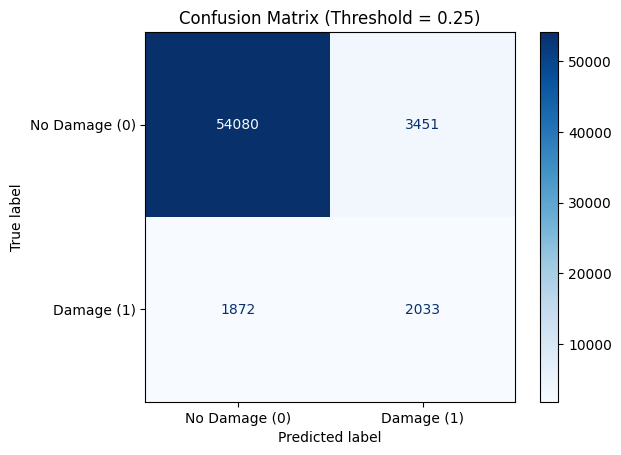

In [7]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Re-calculate predictions for the 0.25 threshold
optimal_threshold = 0.25
y_pred_optimal = (y_probs_local >= optimal_threshold).astype(int)

# 2. Calculate the new Accuracy
new_accuracy = accuracy_score(y_val_local, y_pred_optimal)
print(f"--- Performance at {optimal_threshold} Threshold ---")
print(f"Validation Accuracy : {new_accuracy:.4f}")

# 3. Display the Confusion Matrix to see the real-world impact
print("\nPlotting Confusion Matrix...")
ConfusionMatrixDisplay.from_predictions(
    y_val_local, 
    y_pred_optimal, 
    display_labels=['No Damage (0)', 'Damage (1)'],
    cmap='Blues'
)
plt.title(f"Confusion Matrix (Threshold = {optimal_threshold})")
plt.show()

# XG Boost

In [8]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


Calculated scale_pos_weight: 14.73
Training XGBoost model... (This is usually faster than Random Forest)



--- XGBoost Baseline Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.82      0.89     57531
           1       0.23      0.81      0.36      3905

    accuracy                           0.82     61436
   macro avg       0.61      0.81      0.63     61436
weighted avg       0.94      0.82      0.86     61436

ROC-AUC Score: 0.9030


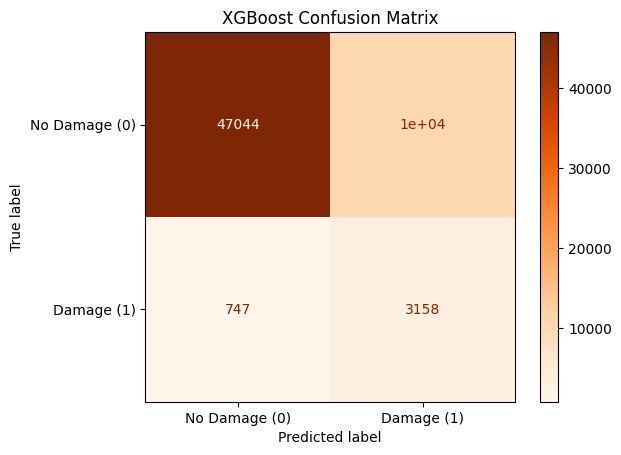

In [9]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Calculate the ideal 'scale_pos_weight'
# Formula: (Total Negative Class) / (Total Positive Class)
neg_class_count = (y_train_local == 0).sum()
pos_class_count = (y_train_local == 1).sum()
spw = neg_class_count / pos_class_count

print(f"Calculated scale_pos_weight: {spw:.2f}")

# 2. Initialize the XGBoost Classifier
# We set eval_metric to 'auc' because ROC-AUC is our best indicator of success here
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=spw,
    n_estimators=200,       # Number of gradient boosted trees
    max_depth=5,            # How deep the trees can grow (5-7 is usually a good start)
    learning_rate=0.1,      # Step size shrinkage to prevent overfitting
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)

# 3. Train the model
print("Training XGBoost model... (This is usually faster than Random Forest)")
xgb_model.fit(X_train_local, y_train_local)

# 4. Make Predictions
# By default, this uses the standard 0.50 threshold
y_pred_xgb = xgb_model.predict(X_val_local)
y_probs_xgb = xgb_model.predict_proba(X_val_local)[:, 1]

# 5. Evaluate the Results
print("\n--- XGBoost Baseline Evaluation ---")
print(classification_report(y_val_local, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_val_local, y_probs_xgb):.4f}")

# 6. Plot the Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_val_local, 
    y_pred_xgb, 
    display_labels=['No Damage (0)', 'Damage (1)'],
    cmap='Oranges' # Using a different color to distinguish from the RF matrix
)
plt.title("XGBoost Confusion Matrix")
plt.show()

In [10]:
import numpy as np
# Assuming 'skf' and 'scoring_metrics' are still defined from Step 4

print("Running 5-Fold Stratified CV for XGBoost... (This might take a minute)")

# We pass in the xgb_model we just created with the scale_pos_weight
xgb_cv_results = cross_validate(
    xgb_model, 
    X_train_processed, 
    y_train, 
    cv=skf, 
    scoring=scoring_metrics, 
    n_jobs=-1 
)

# Print the results clearly
print("\n--- XGBoost Cross Validation Results (Average over 5 folds) ---")
for metric in scoring_metrics:
    mean_score = np.mean(xgb_cv_results[f'test_{metric}'])
    std_score = np.std(xgb_cv_results[f'test_{metric}'])
    
    print(f"{metric.capitalize():<12}: {mean_score:.4f} (+/- {std_score:.4f})")

Running 5-Fold Stratified CV for XGBoost... (This might take a minute)

--- XGBoost Cross Validation Results (Average over 5 folds) ---
Accuracy    : 0.8156 (+/- 0.0026)
Precision   : 0.2315 (+/- 0.0030)
Recall      : 0.8193 (+/- 0.0037)
F1          : 0.3610 (+/- 0.0039)
Roc_auc     : 0.9029 (+/- 0.0023)


In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Get the raw probabilities from the XGBoost model
# (You might already have this from the previous cell, but re-calculating to be safe)
y_probs_xgb = xgb_model.predict_proba(X_val_local)[:, 1]

# 2. Define a higher range of thresholds to test
thresholds_xgb = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

print("--- XGBoost Threshold Tuning Results ---")
print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 47)

# 3. Loop through and evaluate
for t in thresholds_xgb:
    y_pred_custom = (y_probs_xgb >= t).astype(int)
    
    precision = precision_score(y_val_local, y_pred_custom, zero_division=0)
    recall = recall_score(y_val_local, y_pred_custom, zero_division=0)
    f1 = f1_score(y_val_local, y_pred_custom, zero_division=0)
    
    print(f"{t:<10.2f} | {precision:<10.4f} | {recall:<10.4f} | {f1:<10.4f}")

--- XGBoost Threshold Tuning Results ---
Threshold  | Precision  | Recall     | F1-Score  
-----------------------------------------------
0.50       | 0.2314     | 0.8087     | 0.3599    
0.60       | 0.2909     | 0.7373     | 0.4172    
0.70       | 0.3649     | 0.6366     | 0.4639    
0.75       | 0.4147     | 0.5805     | 0.4838    
0.80       | 0.4685     | 0.5127     | 0.4896    
0.85       | 0.5299     | 0.4269     | 0.4728    
0.90       | 0.6360     | 0.3360     | 0.4397    
0.95       | 0.7642     | 0.1900     | 0.3043    


# Final Submission

In [13]:
import pandas as pd

# 1. Load the sample submission to get the correct formatting and IDs
# (Kaggle usually requires the exact IDs from the test set)
submission_df = pd.read_csv('sample_submission.csv')

# 2. Get the raw probabilities for the blind test set
print("Generating predictions on the test set...")
test_probs_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

# 3. Apply your winning threshold (0.80)
optimal_xgb_threshold = 0.80
test_preds_final = (test_probs_xgb >= optimal_xgb_threshold).astype(int)

# 4. Assign the predictions to the target column in the submission file
# Make sure the column name matches exactly what Kaggle expects ('INDICATED_DAMAGE')
submission_df['INDICATED_DAMAGE'] = test_preds_final

# 5. Save the final file! 
# index=False prevents pandas from adding an extra column of row numbers
submission_filename = 'xgboost_final_submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Success! Saved to {submission_filename}.")
print("You are ready to upload this file to Kaggle!")

Generating predictions on the test set...
Success! Saved to xgboost_final_submission.csv.
You are ready to upload this file to Kaggle!
